# Comparaison Experts (Steam) vs Folksonomy (Joueurs)

## Objectif
S'appuyer sur **Lu et al. (2010)** pour comparer les métadonnées officielles de Steam (Genres et Catégories fournis par les développeurs) avec les tags utilisateurs.

Cette analyse permet de voir si les utilisateurs apportent une valeur ajoutée (granularité) ou s'ils se contentent de répéter les catégories officielles.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

db_path = '../data/2024-12-13.steam.db'
conn = sqlite3.connect(db_path)

# 1. Extraction des Genres Experts
query_genres = """
SELECT g.id, g.name, gr.label as expert_genre
FROM games g
JOIN game_genre gg ON g.id = gg.game_id
JOIN genres gr ON gg.genre_id = gr.id
"""
df_expert_genres = pd.read_sql_query(query_genres, conn)

# 2. Extraction des Catégories Experts (ex: Multi-player, Steam Achievements)
query_cats = """
SELECT g.id, c.label as expert_category
FROM games g
JOIN game_category gc ON g.id = gc.game_id
JOIN categories c ON gc.category_id = c.id
"""

try:
    df_expert_cats = pd.read_sql_query(query_cats, conn)
except Exception:
    df_expert_cats = pd.DataFrame(columns=['id', 'label'])

conn.close()

# Chargement de notre base folksonomique structurée pour comparer
df_folk = pd.read_csv('../data/Games_Gameplay_Taxonomy.csv')

# Conversion de la date (format yymmdd)
df_folk['release_year'] = pd.to_datetime(df_folk['game_release_date'], format='%y%m%d', errors='coerce').dt.year
# Filtrage pour garder des années cohérentes (ex: 1990-2025)
df_folk = df_folk[(df_folk['release_year'] >= 1990) & (df_folk['release_year'] <= 2025)]

print(f"Données experts chargées. Nombre de jeux avec genres officiels : {df_expert_genres['id'].nunique()}")

Données experts chargées. Nombre de jeux avec genres officiels : 112332


*On a 112332 jeux avec un genre officiels.*

## 1. Analyse Quantitative : Richesse de l'information

Comparons le nombre moyen de labels par jeu entre experts et joueurs.

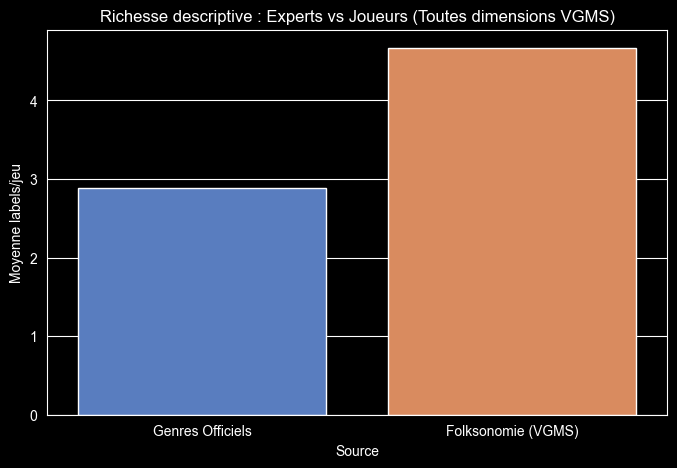

In [2]:
expert_counts = df_expert_genres.groupby('id').size()

# Dimensions VGMS définies dans la taxonomie (voir 2_Gameplay_Tag_Taxonomy.ipynb)
vgms_dimensions = ['Genre', 'Mechanics', 'Theme', 'Setting', 'Mood', 'Aesthetics', 'Perspective', 'Players']
# On s'assure que les colonnes existent
available_dims = [d for d in vgms_dimensions if d in df_folk.columns]

folk_counts = df_folk.set_index('game_id')[available_dims].notna().sum(axis=1)

stats = pd.DataFrame({
    'Source': ['Genres Officiels', 'Folksonomie (VGMS)'],
    'Moyenne labels/jeu': [expert_counts.mean(), folk_counts.mean()]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=stats, x='Source', y='Moyenne labels/jeu', hue='Source', palette='muted', legend=False)
plt.title("Richesse descriptive : Experts vs Joueurs (Toutes dimensions VGMS)")
plt.show()

*Les joueurs fournissent quasiment 5 labels par jeu (toutes dimensions confondues), tandis que les experts se limitent à presque 3 genre officiel par jeu. Cela confirme que les joueurs apportent une richesse descriptive bien supérieure, couvrant non seulement les genres mais aussi les mécaniques, l'ambiance, et d'autres aspects du gameplay.*

## 2. Analyse de l'Accord (Consensus) pour tous les genres

Analyse comparative pour chaque genre officiel : quel pourcentage est aussi confirmé par les joueurs ?

**Note importante** : Seuls les genres présents dans la folksonomie (basée sur le gameplay) sont analysés.
Les genres officiels qui n'existent pas dans la folksonomie (éléments marketing, distribution, statut de développement)
sont exclus car ils n'ont pas d'équivalent pertinent pour cette analyse de consensus.

Genres uniques présents dans la folksonomie : 99

SECTION 1 : GENRES PRÉSENTS DANS LA FOLKSONOMIE (avec Intervalle de Confiance 95%)

Genre Officiel  Nombre de jeux (Experts)  Taux d'Accord (%)  Marge Erreur (%)
        Casual                     44955          71.082193          0.419112
        Action                     48636          68.679579          0.412197
        Racing                      3998          68.359180          1.441640
      Strategy                     22127          67.731730          0.615997
     Adventure                     46476          66.645150          0.428653
    Simulation                     23007          66.397183          0.610364
           RPG                     22280          64.753142          0.627320

--------------------------------------------------------------------------------
STATISTIQUES GLOBALES
--------------------------------------------------------------------------------
Taux d'accord moyen : 67.66%
Taux d'accord médian : 67.73

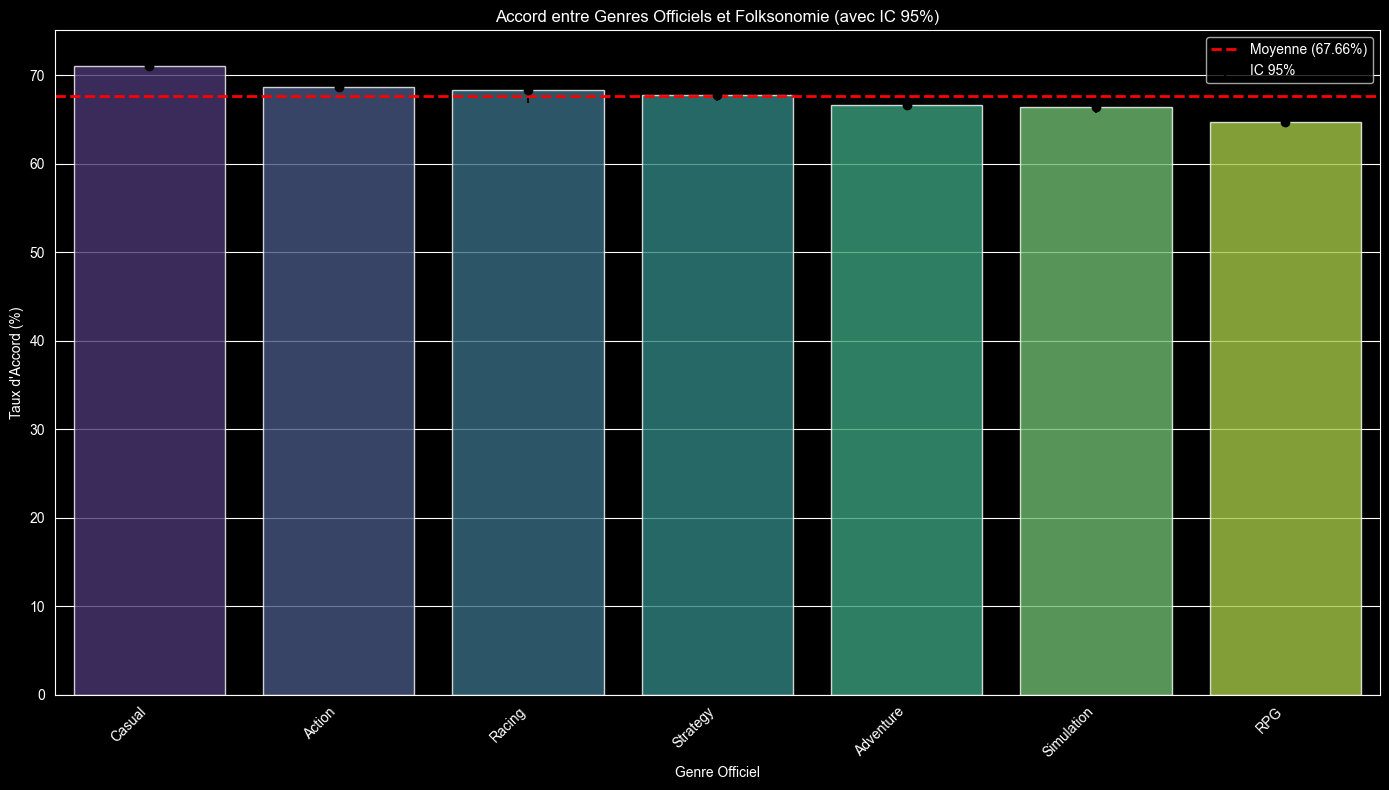



SECTION 2 : GENRES ABSENTS DE LA FOLKSONOMIE

Ces genres officiels n'existent pas dans la folksonomie (basée sur le gameplay).
                Genre  Nombre de jeux (Experts)
                Indie                     79089
         Early Access                     12085
         Free To Play                      9757
               Sports                      4582
Massively Multiplayer                      3120
            Utilities                       931
Design & Illustration                       538
              Violent                       469
 Animation & Modeling                       437
            Education                       431
     Video Production                       313
     Game Development                       289
                 Gore                       285
    Software Training                       211
     Audio Production                       211
        Photo Editing                       148
       Web Publishing                       104
       

In [3]:
# 1. Extraire les genres UNIQUES de la folksonomie
folk_genres_str = df_folk['Genre'].dropna().astype(str)
folk_genres_set = set()
for genres_str in folk_genres_str:
    # Chaque cellule peut contenir plusieurs genres séparés par des virgules
    genres_in_cell = [g.strip() for g in genres_str.split(',')]
    folk_genres_set.update(genres_in_cell)

print(f"Genres uniques présents dans la folksonomie : {len(folk_genres_set)}")

# 2. Obtenir tous les genres officiels uniques
all_expert_genres = set(df_expert_genres['expert_genre'].unique())

# 3. Séparer les genres : PRÉSENTS vs ABSENTS de la folksonomie
genres_in_both = all_expert_genres.intersection(folk_genres_set)
genres_absent_from_folk = all_expert_genres - folk_genres_set

# Préparation du croisement
common_ids = set(df_expert_genres['id']).intersection(set(df_folk['game_id']))

# ===== SECTION 1 : GENRES PRÉSENTS DANS LA FOLKSONOMIE =====
comparison_data = []

for genre in sorted(genres_in_both):
    # Jeux avec ce genre dans les experts
    expert_games = set(df_expert_genres[df_expert_genres['expert_genre'] == genre]['id'])

    if len(expert_games) == 0:
        continue

    # Jeux avec ce genre dans la folksonomie
    folk_games = set(df_folk[df_folk['Genre'].str.contains(genre, na=False)]['game_id'])

    # Calcul du consensus
    n = len(expert_games)
    k = len(expert_games.intersection(folk_games))
    agreement = k / n * 100

    comparison_data.append({
        'Genre Officiel': genre,
        'Nombre de jeux (Experts)': n,
        'Confirmés par Joueurs': k,
        'Taux d\'Accord (%)': agreement
    })

# Créer le DataFrame de comparaison
df_comparison = pd.DataFrame(comparison_data)

# Ajout de l'intervalle de confiance (95%)
# Formule : 1.96 * sqrt(p(1-p)/n)
df_comparison['Marge Erreur (%)'] = 1.96 * np.sqrt(
    (df_comparison['Taux d\'Accord (%)']/100 * (1 - df_comparison['Taux d\'Accord (%)']/100))
    / df_comparison['Nombre de jeux (Experts)']
) * 100

df_comparison = df_comparison.sort_values('Taux d\'Accord (%)', ascending=False)

print("\n" + "="*80)
print("SECTION 1 : GENRES PRÉSENTS DANS LA FOLKSONOMIE (avec Intervalle de Confiance 95%)")
print("="*80 + "\n")
print(df_comparison[['Genre Officiel', 'Nombre de jeux (Experts)', 'Taux d\'Accord (%)', 'Marge Erreur (%)']].to_string(index=False))

# Calculer les statistiques
mean_agreement = df_comparison['Taux d\'Accord (%)'].mean()
median_agreement = df_comparison['Taux d\'Accord (%)'].median()

print("\n" + "-"*80)
print("STATISTIQUES GLOBALES")
print("-"*80)
print(f"Taux d'accord moyen : {mean_agreement:.2f}%")
print(f"Taux d'accord médian : {median_agreement:.2f}%")

# Visualisation des genres comparables avec barres d'erreur
plt.figure(figsize=(14, 8))
plt.errorbar(x=df_comparison['Genre Officiel'], y=df_comparison['Taux d\'Accord (%)'],
             yerr=df_comparison['Marge Erreur (%)'], fmt='o', color='black', label='IC 95%')
sns.barplot(data=df_comparison, x='Genre Officiel', y='Taux d\'Accord (%)', hue='Genre Officiel', palette='viridis', legend=False, alpha=0.8)
plt.axhline(y=mean_agreement, color='red', linestyle='--', linewidth=2, label=f'Moyenne ({mean_agreement:.2f}%)')
plt.title("Accord entre Genres Officiels et Folksonomie (avec IC 95%)")
plt.xlabel("Genre Officiel")
plt.ylabel("Taux d'Accord (%)")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# ===== SECTION 2 : GENRES ABSENTS DE LA FOLKSONOMIE =====
if genres_absent_from_folk:
    print("\n\n" + "="*80)
    print("SECTION 2 : GENRES ABSENTS DE LA FOLKSONOMIE")
    print("="*80)
    print("\nCes genres officiels n'existent pas dans la folksonomie (basée sur le gameplay).")

    absent_data = []
    for genre in sorted(genres_absent_from_folk):
        expert_count = len(set(df_expert_genres[df_expert_genres['expert_genre'] == genre]['id']))
        absent_data.append({
            'Genre': genre,
            'Nombre de jeux (Experts)': expert_count
        })

    df_absent = pd.DataFrame(absent_data).sort_values('Nombre de jeux (Experts)', ascending=False)
    print(df_absent.to_string(index=False))

*Les genres officiels sont très majoritairement absents de la folksonomie, ce qui est conforme à la littérature (Lu et al. 2010). Cependant, les genres qui sont présents dans la folksonomie montrent un taux d'accord moyen élevé.*

## 3. Analyse Temporelle de l'Accord

L'accord entre experts et joueurs a-t-il évolué avec le temps ? Les joueurs sont-ils plus en phase avec les définitions officielles sur les jeux récents ?

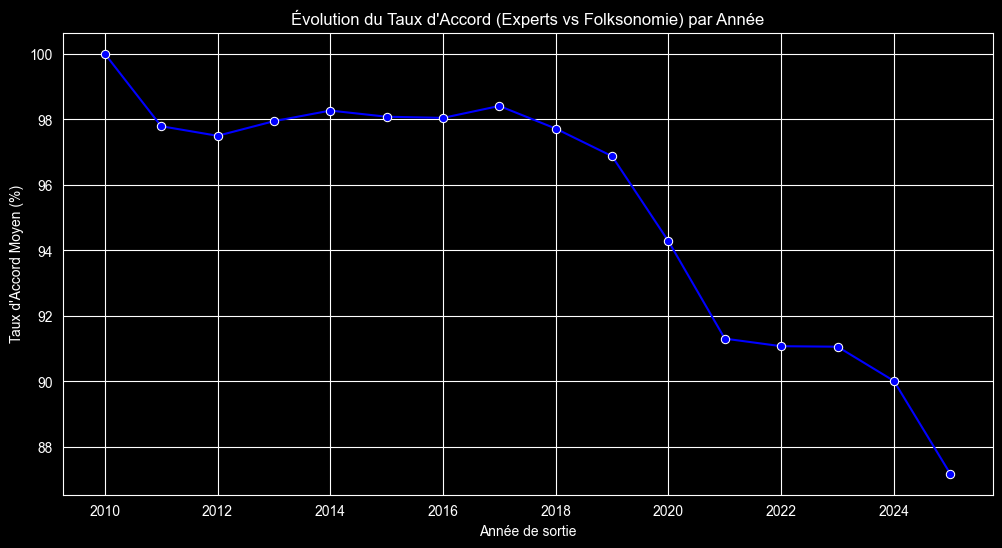

In [4]:
# Préparation des données pour l'analyse temporelle
df_expert_with_year = df_expert_genres.merge(df_folk[['game_id', 'release_year', 'Genre']], left_on='id', right_on='game_id', how='inner')

# On ne garde que les genres présents dans la folksonomie
df_expert_with_year = df_expert_with_year[df_expert_with_year['expert_genre'].isin(genres_in_both)]

# Fonction pour vérifier l'accord ligne par ligne
def check_agreement(row):
    if pd.isna(row['Genre']):
        return False
    folk_genres_list = [g.strip() for g in row['Genre'].split(',')]
    return row['expert_genre'] in folk_genres_list

df_expert_with_year['agreement'] = df_expert_with_year.apply(check_agreement, axis=1)

# Groupement par année
temporal_agreement = df_expert_with_year.groupby('release_year')['agreement'].mean() * 100

# Filtrer les années avec trop peu de données (focus 2010-2025)
temporal_agreement = temporal_agreement[temporal_agreement.index >= 2010]

plt.figure(figsize=(12, 6))
sns.lineplot(x=temporal_agreement.index, y=temporal_agreement.values, marker='o', color='b')
plt.title("Évolution du Taux d'Accord (Experts vs Folksonomie) par Année")
plt.xlabel("Année de sortie")
plt.ylabel("Taux d'Accord Moyen (%)")
plt.grid(True)
plt.show()

*On ce rend compte que au fur et à mesure du temps, les joueurs sont de moins en moins d'accord avec les genres officiels. Cela peut s'expliquer par l'évolution rapide des genres de jeux, la diversification des mécaniques, et le fait que les joueurs utilisent des tags plus spécifiques que les catégories génériques fournies par les développeurs. Le vocabulaire des joueurs évolue plus rapidement que celui des experts, ce qui peut créer un écart croissant dans la perception des genres au fil du temps.*

## 4. Heatmap de Correspondance : Experts vs Folksonomie

Au-delà du simple accord binaire, comment les genres officiels se projettent-ils sur les genres folksonomiques ?

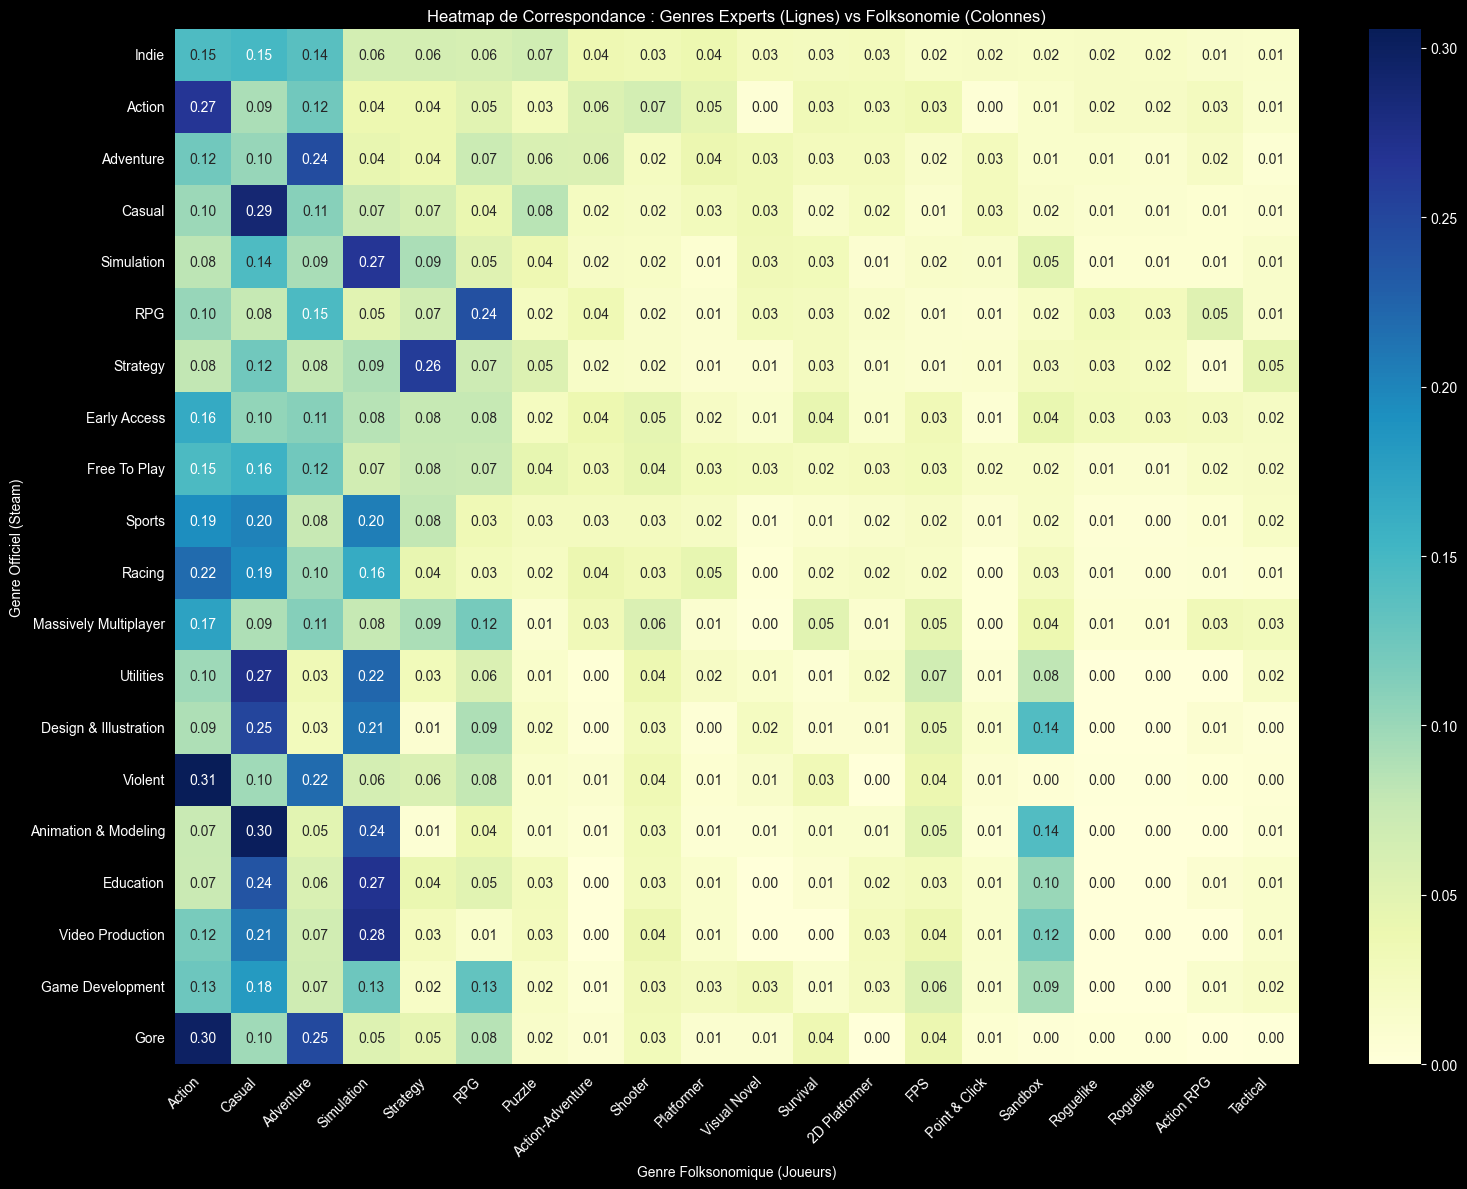

In [5]:
# Sélection des Top 20 genres pour la lisibilité
top_expert_genres = df_expert_genres['expert_genre'].value_counts().head(20).index
all_folk_genres = []
for x in df_folk['Genre'].dropna():
    all_folk_genres.extend([g.strip() for g in x.split(',')])
top_folk_genres = pd.Series(all_folk_genres).value_counts().head(20).index

# Création de la matrice de confusion
heatmap_data = pd.DataFrame(0, index=top_expert_genres, columns=top_folk_genres)

# On itère sur les jeux communs
df_merged = df_expert_genres.merge(df_folk[['game_id', 'Genre']], left_on='id', right_on='game_id')

for idx, row in df_merged.iterrows():
    exp_g = row['expert_genre']
    if exp_g in top_expert_genres and pd.notna(row['Genre']):
        folk_gs = [g.strip() for g in row['Genre'].split(',')]
        for folk_g in folk_gs:
            if folk_g in top_folk_genres:
                heatmap_data.loc[exp_g, folk_g] += 1

# Normalisation par ligne (Probabilité conditionnelle P(Folk|Expert))
heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

plt.figure(figsize=(16, 12))
sns.heatmap(heatmap_norm, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title("Heatmap de Correspondance : Genres Experts (Lignes) vs Folksonomie (Colonnes)")
plt.ylabel("Genre Officiel (Steam)")
plt.xlabel("Genre Folksonomique (Joueurs)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Cas d'Étude : Accord vs Désaccord

Analysons des exemples concrets de jeux où le consensus est fort et d'autres où il est faible.

In [6]:
def get_examples(genre, agreement_type='match', n=3):
    # agreement_type: 'match' (Expert=X, Folk=X), 'miss' (Expert=X, Folk!=X)
    expert_games_ids = set(df_expert_genres[df_expert_genres['expert_genre'] == genre]['id'])
    examples = []
    for gid in expert_games_ids:
        if gid not in df_folk['game_id'].values: continue
        folk_row = df_folk[df_folk['game_id'] == gid].iloc[0]
        if pd.isna(folk_row['Genre']): continue

        folk_genres = [g.strip() for g in folk_row['Genre'].split(',')]
        is_match = genre in folk_genres

        if (agreement_type == 'match' and is_match) or (agreement_type == 'miss' and not is_match):
            examples.append({
                'Jeu': folk_row['game_name'],
                'Genre Officiel': genre,
                'Genres Folksonomie': folk_row['Genre'],
                'Mécaniques': folk_row['Mechanics'] if 'Mechanics' in folk_row else 'N/A'
            })
            if len(examples) >= n: break
    return pd.DataFrame(examples)

# Exemples
top_genre = df_comparison.iloc[0]['Genre Officiel']
bottom_genre = df_comparison.iloc[-1]['Genre Officiel']

print(f"\n--- Exemples d'ACCORD pour le genre '{top_genre}' ---")
print(get_examples(top_genre, 'match').to_string(index=False))

print(f"\n--- Exemples de DÉSACCORD pour le genre '{bottom_genre}' ---")
print(f"(L'expert dit '{bottom_genre}', mais les joueurs ne l'ont pas tagué ainsi)")
print(get_examples(bottom_genre, 'miss').to_string(index=False))


--- Exemples d'ACCORD pour le genre 'Casual' ---
              Jeu Genre Officiel                                                                           Genres Folksonomie                Mécaniques
       Urban Tale         Casual Simulation, Casual, RPG, Adventure, Life Sim, Sandbox, Choose Your Own Adventure, Management                       NaN
Gachi Finder 3000         Casual                                 Casual, Strategy, God Game, Simulation, FPS, Survival Horror Open World Survival Craft
         Gun Beat         Casual                                                                               Action, Casual                       NaN

--- Exemples de DÉSACCORD pour le genre 'RPG' ---
(L'expert dit 'RPG', mais les joueurs ne l'ont pas tagué ainsi)
                         Jeu Genre Officiel                                                                                                                     Genres Folksonomie                            Mécaniques
          

*Le genre avec le meilleur accord, 'Casual' montre que les joueurs utilisent massivement ce genre dans leurs tags, confirmant la pertinence de ce label pour décrire le gameplay. En revanche, le genre avec le pire accord 'RPG' révèle que les joueurs ne reconnaissent pas ce label comme pertinent pour ces jeux, ce qui peut indiquer une divergence dans la perception du genre ou une évolution du vocabulaire des joueurs par rapport aux classifications officielles.*

## 6. Le "Surplus Folksonomique" : Ce que les experts ne disent pas

Analysons les dimensions de notre taxonomie qui n'existent pratiquement pas dans les genres officiels (ex: Mécaniques, Mood).

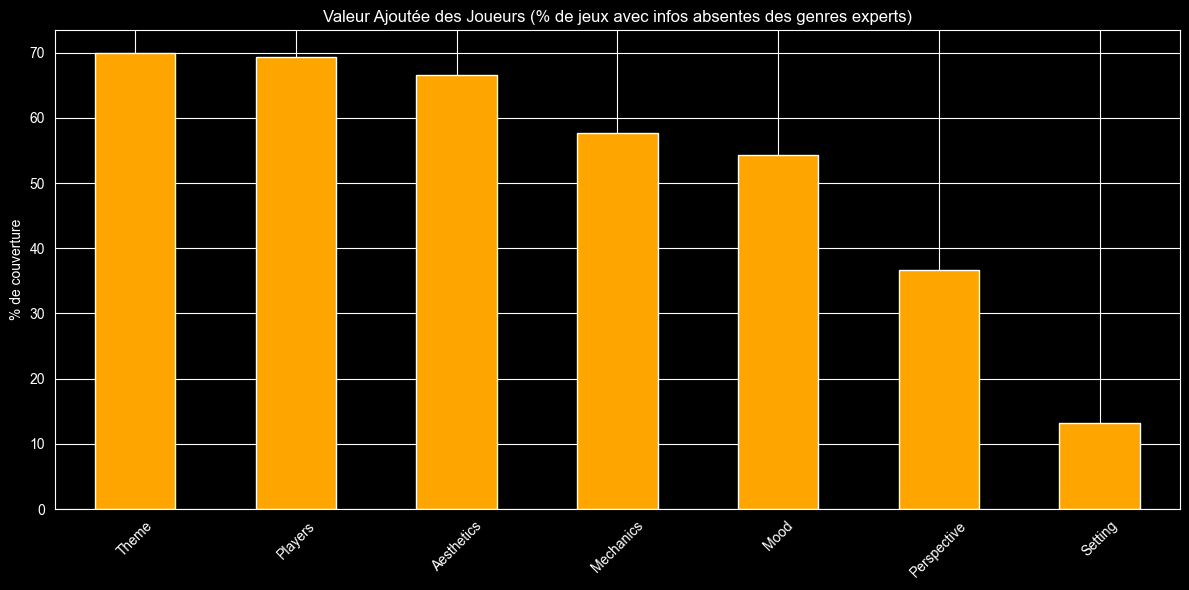

In [7]:
# Analyse de toutes les dimensions VGMS sauf 'Genre' (qui est comparé aux experts)
dims_to_analyze = [d for d in available_dims if d != 'Genre']
surplus = df_folk[dims_to_analyze].notna().mean() * 100
surplus = surplus.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
surplus.plot(kind='bar', color='orange')
plt.title("Valeur Ajoutée des Joueurs (% de jeux avec infos absentes des genres experts)")
plt.ylabel("% de couverture")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Les joueurs fournissent massivement des informations sur les thèmes, les joueurs, l'aesthétiques, et surtout les mécaniques de jeu, qui sont des aspects cruciaux du gameplay mais qui ne sont pas capturés par les genres officiels. Cela confirme que la folksonomie apporte une richesse descriptive complémentaire, en couvrant des dimensions que les experts ne prennent pas en compte dans leurs classifications génériques.*

## Conclusion de la comparaison

Cette analyse confirme et nuance les observations de la littérature (Lu et al., 2010) sur la plateforme Steam :

### 1. Richesse Descriptive et Granularité
Les joueurs apportent une valeur ajoutée significative en termes de volume et de précision. Avec près de **5 labels par jeu contre 3 pour les experts**, la folksonomie couvre des dimensions absentes des classifications officielles, notamment les **mécaniques de jeu**, l'**ambiance**, les **thèmes** et l'**esthétique**. Ce "surplus folksonomique" comble les lacunes des genres génériques officiels.

### 2. Consensus et Divergences
*   **Accord Global** : Pour les genres présents dans les deux systèmes, le taux d'accord est généralement élevé, validant la pertinence de certains termes officiels (ex: 'Casual').
*   **Désaccords Notables** : Certains genres majeurs comme 'RPG' montrent un faible consensus, suggérant une divergence de perception ou une définition trop large côté experts que les joueurs ne valident pas.
*   **Absence de Correspondance** : Une grande majorité des genres officiels (souvent liés au marketing ou à la distribution) n'ont aucun équivalent dans le vocabulaire de gameplay des joueurs.

### 3. Évolution Temporelle : Un Fossé Grandissant
Un constat frappant est la **baisse progressive de l'accord au fil du temps**. Les joueurs s'éloignent de plus en plus des classifications officielles pour les jeux récents. Cela s'explique par :
*   L'évolution rapide et la diversification des genres de jeux.
*   L'émergence de mécaniques hybrides que les catégories rigides des experts peinent à capturer.
*   Un vocabulaire joueur qui évolue plus vite, privilégiant des tags spécifiques là où les développeurs restent sur des termes génériques.

### Synthèse
La folksonomie ne se contente pas de répéter la classification experte ; elle la **complète** (mécaniques, mood) et la **challenge** (redéfinition des genres, précision accrue). L'écart grandissant entre les deux vocabulaires souligne la nécessité de prendre en compte les tags utilisateurs pour une classification moderne et pertinente des jeux vidéo.
